In [69]:
import pandas as pd
import glob
from datetime import date
import numpy as np
from scipy import stats

In [2]:
path = r'contaminantes_N5'
filenames = glob.glob(path + "/*.csv")

dfs = []
for filename in filenames:
    dfs.append(pd.read_csv(filename))

big_frame = pd.concat(dfs, ignore_index=True)

In [3]:
big_frame = big_frame.dropna()

In [25]:
big_frame['date'] = pd.to_datetime(big_frame['date'], format='mixed')

In [26]:
big_frame.info()

<class 'pandas.DataFrame'>
Index: 2864358 entries, 7 to 5394140
Data columns (total 5 columns):
 #   Column        Dtype         
---  ------        -----         
 0   date          datetime64[us]
 1   id_station    str           
 2   id_parameter  str           
 3   valor         float64       
 4   unit          float64       
dtypes: datetime64[us](1), float64(2), str(2)
memory usage: 147.9 MB


In [27]:
big_frame.columns

Index(['date', 'id_station', 'id_parameter', 'valor', 'unit'], dtype='str')

In [28]:
big_frame['id_parameter'].unique()

<ArrowStringArray>
['CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PMCO', 'SO2']
Length: 9, dtype: str

In [83]:
big_frame.groupby([big_frame['id_parameter'], pd.Grouper(
    key = 'date',
    freq= 'YE'
)])['valor'].agg([
    'mean', 
    'median', 
    ('mode', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)])

mean  median   mode
id_parameter date                                
CO           2024-12-31   0.474250    0.36   0.25
             2025-12-31   0.524322    0.44   0.30
             2026-12-31   0.734344    0.56   0.30
NO           2024-12-31  13.618770    3.00   1.00
             2025-12-31  11.574989    3.00   1.00
             2026-12-31  21.289761    4.00   1.00
NO2          2024-12-31  23.512982   21.00  14.00
             2025-12-31  21.956945   20.00  15.00
             2026-12-31  28.795257   26.00  12.00
NOX          2024-12-31  37.191113   25.00  14.00
             2025-12-31  34.220856   25.00  14.00
             2026-12-31  49.948652   30.00  14.00
O3           2024-12-31  32.431235   25.00   1.00
             2025-12-31  32.509778   25.00   2.00
             2026-12-31  32.252186   29.00   2.00
PM10         2024-12-31  43.298745   38.00  26.00
             2025-12-31  38.853138   34.00  23.00
             2026-12-31  52.481920   47.00  42.00
PM2.5        2024-12-31  20.423306   18.00  13.00
             2025-12-31  19.630292   18.00  13.00
             2026-12-31  20.784871   18.00  16.00
PMCO         2024-12-31  19.348808   16.00   6.00
             2025-12-31  16.023970   13.00   7.00
             2026-12-31  26.644444   25.00   8.00
SO2          2024-12-31   2.573549    1.00   1.00
             2025-12-31   2.818824    1.00   1.00
             2026-12-31   3.237988    2.00   1.00

In [82]:
big_frame.groupby([big_frame['id_parameter'], pd.Grouper(
    key = 'date',
    freq= 'YE'
)])['valor'].agg(['var', 'std', ('range' ,np.ptp)])

var        std   range
id_parameter date                                      
CO           2024-12-31     0.171169   0.413726    5.44
             2025-12-31     0.144799   0.380524    6.09
             2026-12-31     0.299130   0.546927    5.16
NO           2024-12-31   814.528434  28.539945  498.00
             2025-12-31   557.967896  23.621344  525.00
             2026-12-31  1677.417645  40.956289  365.00
NO2          2024-12-31   194.691562  13.953192  140.00
             2025-12-31   160.485809  12.668299  120.00
             2026-12-31   320.355573  17.898480  119.00
NOX          2024-12-31  1395.985761  37.362893  569.00
             2025-12-31   994.384687  31.533866  574.00
             2026-12-31  2757.556972  52.512446  450.00
O3           2024-12-31   789.941928  28.105906  187.00
             2025-12-31   784.402187  28.007181  168.00
             2026-12-31   665.822324  25.803533  138.00
PM10         2024-12-31   817.831173  28.597748  581.00
             2025-12-31   667.185628  25.829937  441.00
             2026-12-31   992.330600  31.501279  291.00
PM2.5        2024-12-31   174.320505  13.203049  311.00
             2025-12-31   138.493721  11.768336  268.00
             2026-12-31   154.690875  12.437479  130.00
PMCO         2024-12-31   211.749759  14.551624  303.00
             2025-12-31   185.678479  13.626389  267.00
             2026-12-31   272.899542  16.519671  110.00
SO2          2024-12-31    23.187915   4.815383  185.00
             2025-12-31    27.221226   5.217396  247.00
             2026-12-31    18.564628   4.308669   53.00

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

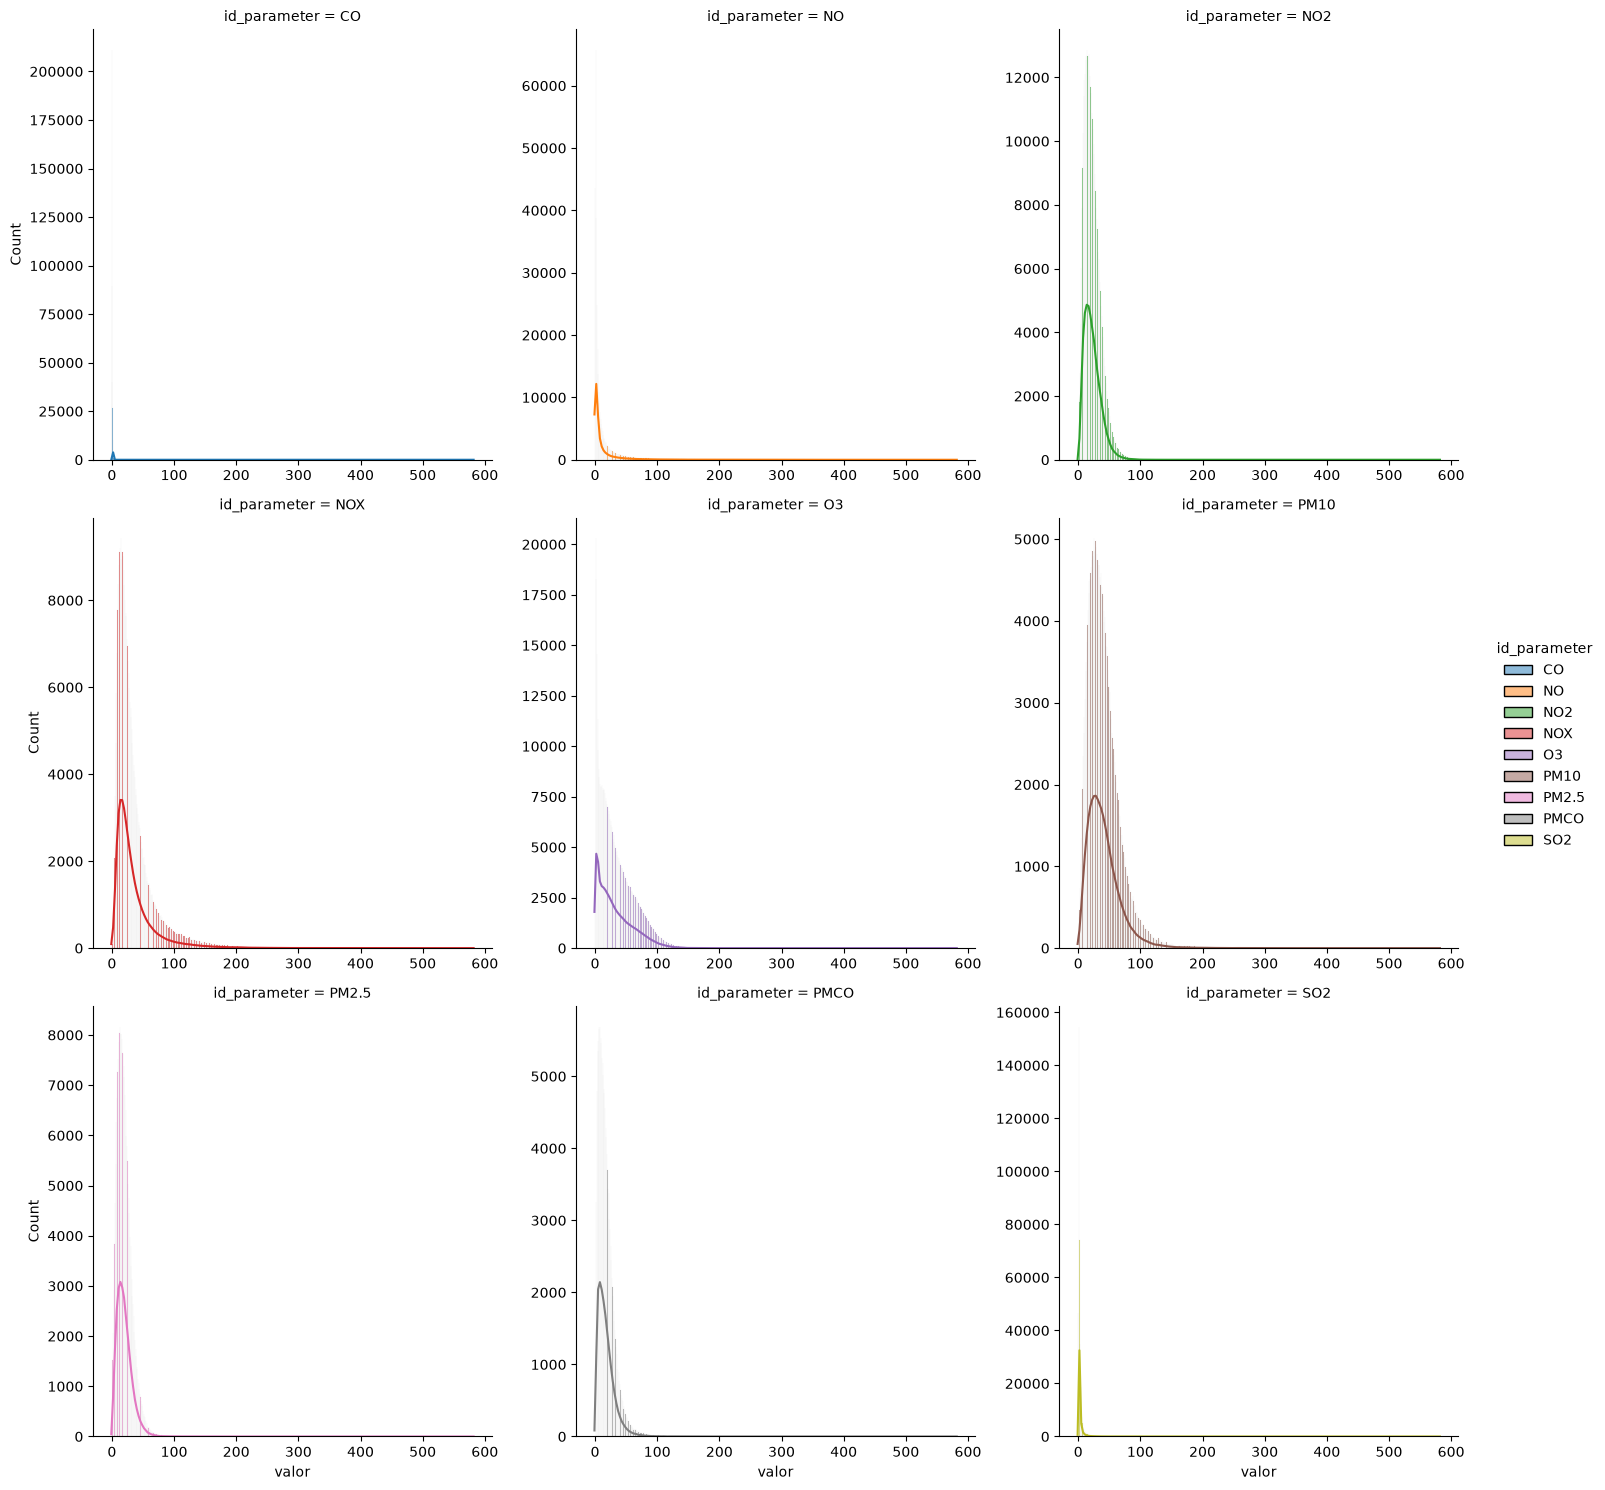

In [ ]:
sns.displot(data=big_frame, x='valor', hue='id_parameter', col='id_parameter', col_wrap=3, kde=True, facet_kws={'sharex': False, 'sharey': False})
plt.show()